# Level 2 - Task 2

## Price Range Analysis

### Objective

Determine the most common price range among restaurants, calculate the average rating for each price range, and identify the rating color associated with the highest average rating.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
df = df.dropna(subset=['Cuisines'])

print(df.shape)

(9542, 21)


In [4]:
price_range_counts = df["Price range"].value_counts()

print(price_range_counts)

Price range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64


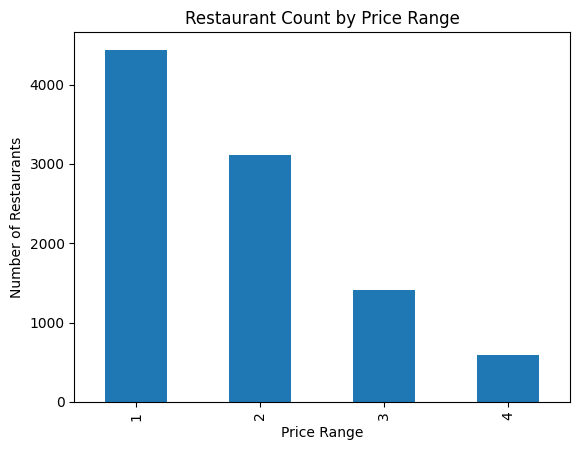

In [5]:
price_range_counts.plot(kind='bar')

plt.title("Restaurant Count by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.show()

In [6]:
average_rating_by_price = (
    df.groupby("Price range")
    ["Aggregate rating"]
    .mean()
)

print(average_rating_by_price)

Price range
1    1.997476
2    2.941054
3    3.682633
4    3.817918
Name: Aggregate rating, dtype: float64


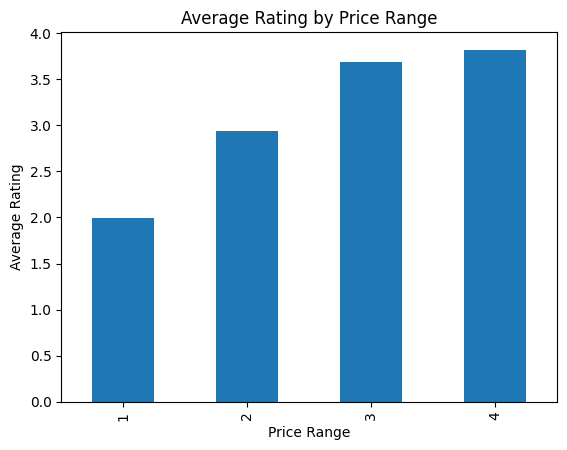

In [7]:
average_rating_by_price.plot(kind='bar')

plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")

plt.show()

In [8]:
rating_color_analysis = (
    df.groupby("Rating color")
    ["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

print(rating_color_analysis)

Rating color
Dark Green    4.659667
Green         4.167904
Yellow        3.683063
Orange        3.051339
Red           2.297849
White         0.000000
Name: Aggregate rating, dtype: float64


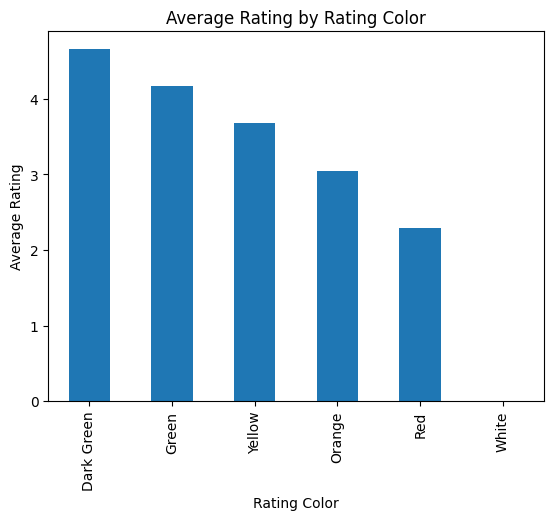

In [9]:
rating_color_analysis.plot(kind='bar')

plt.title("Average Rating by Rating Color")
plt.xlabel("Rating Color")
plt.ylabel("Average Rating")

plt.show()

In [10]:
highest_color = rating_color_analysis.idxmax()

print("Color with Highest Average Rating:", highest_color)

Color with Highest Average Rating: Dark Green
